# AIFI - Tennessee Eastman smart-factory predictive engine

An end-to-end notebook walkthrough for the **AIFI** (AI Fault Intelligence) prototype. Every cell calls into the modules under `src/` so the notebook stays a thin demo layer rather than a duplicate codebase.

## Industrial context

The Tennessee Eastman Process (TEP) is the *de facto* benchmark for chemical-plant fault detection. We frame the problem as an **Industry 4.0 predictive-maintenance platform** for a smart chemical plant:

* 41 process measurements + 11 manipulated variables sampled every 3 minutes
* **20 fault classes** in this workflow (faulty TEP data only; normal / fault-free baselines are excluded from training)
* outputs feed an animated dashboard (Next.js) via the FastAPI service in `api/main.py`

## Pipeline sections

1. **Data loading** - faulty TEP only; scans **metadata columns first**, then pulls sampled runs via **PyArrow row filters** (keeps RAM low); pre-injection trim; `faultNumber > 0`; stratified **70% / 15% / 15%** train / val / test
2. **Preprocessing** - imputation, scaling, missing-value & outlier audit
3. **EDA** - class distribution, correlation heatmap, sensor trends, PCA
4. **Model training** - Random Forest + XGBoost (XGBoost uses validation mlogloss + early stopping)
5. **Evaluation** - accuracy & log-loss on train / val / test, precision, recall, F1, confusion matrix
6. **Explainability** - native importances + SHAP
7. **Smart-factory simulation** - structured alerts ready for the dashboard

In [1]:
import sys, logging
from pathlib import Path

# Make sure the project root is on the path when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

# Re-running this cell after editing `src/`: drop cached modules so new symbols import
# correctly (otherwise Python keeps an old `src.preprocessing` without e.g.
# `preprocess_train_val_test`). Alternatively: Kernel > Restart & Run All.
_src_keys = [k for k in sys.modules if k == "src" or k.startswith("src.")]
for _k in _src_keys:
    del sys.modules[_k]

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')

from src import config
from src.data_loader import load_tep_dataset, stream_simulation_run
from src.preprocessing import preprocess_train_val_test
from src.eda import (plot_class_distribution, plot_correlation_heatmap,
                     plot_sensor_trends, plot_pca, plot_feature_variance)
from src.models import train_all
from src.evaluation import (evaluate_model, save_evaluation_report,
                            plot_model_comparison, pick_best_model,
                            write_training_summary)
from src.explainability import plot_feature_importance, compute_shap_summary
from src.simulation import build_alert, simulate_live_stream, generate_demo_alerts

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
print('Project root:', config.PROJECT_ROOT)

Project root: C:\Users\LithiChang\AIFI-group_project


## 1. Load the Tennessee Eastman dataset

The first call also builds a parquet cache from the raw `.RData` files (one-off, ~2 minutes). We load **only** `TEP_Faulty_Training` and `TEP_Faulty_Testing`, drop pre-injection rows, keep **active faults** (`faultNumber > 0`), sub-sample simulation runs per fault, then split rows **70% / 15% / 15%** (stratified) into train, validation, and test.

In [2]:
# Larger of train_runs / test_runs caps runs per fault after pooling both faulty archives.
# Lower these on laptops; the loader stays memory-safe via metadata + filtered parquet reads.
ds = load_tep_dataset(train_runs_per_fault=20, test_runs_per_fault=10)
print('Summary:', ds.summary())
ds.class_distribution().head(25)

2026-05-11 13:55:25,037 | INFO | Scanning faulty TEP parquet metadata only (then loading sampled runs) from C:\Users\LithiChang\AIFI-group_project\outputs\cache
2026-05-11 13:55:49,003 | INFO | Final shapes (70/15/15): train=(180544, 52) val=(38688, 52) test=(38688, 52)


Summary: {'train_rows': 180544, 'val_rows': 38688, 'test_rows': 38688, 'n_features': 52, 'n_classes': 20}


,train,val,test
faultNumber,,,
1,9408,2016,2016
2,8960,1920,1920
3,9408,2016,2016
4,9408,2016,2016
5,8512,1824,1824
6,8736,1872,1872
7,8512,1824,1824
8,8512,1824,1824
9,8960,1920,1920


## 2. Preprocess the sensor stream

* schema check (missing / extra TEP tags),
* median imputation (robust to sensor drop-outs),
* StandardScaler (fitted on train only - no leakage),
* outlier audit (`|z| > 6`).

In [3]:
X_train_p, X_val_p, X_test_p, artifacts, audit = preprocess_train_val_test(
    ds.X_train, ds.X_val, ds.X_test,
)
print('Train missing rate (top 5):')
print(audit['missing_train'].head())
print('\nOutlier audit (top 5 sensors):')
print(audit['outliers_train'].head())

2026-05-11 13:55:50,145 | INFO | Preprocessing complete: train=(180544, 52) val=(38688, 52) test=(38688, 52)


Train missing rate (top 5):
         missing_rate
xmeas_1           0.0
xmeas_2           0.0
xmeas_3           0.0
xmeas_4           0.0
xmeas_5           0.0

Outlier audit (top 5 sensors):
          outlier_count  outlier_rate
xmv_11             1478       0.00819
xmeas_21           1381       0.00765
xmeas_22            464       0.00257
xmeas_9             349       0.00193
xmeas_8              98       0.00054


## 3. Exploratory data analysis

Every plot is also saved under `outputs/figures/` so it can be embedded in the dashboard.

In [4]:
plot_class_distribution(ds.y_train, ds.y_test, ds.y_val); plt.show()
plot_correlation_heatmap(X_train_p);            plt.show()
plot_sensor_trends(X_train_p, ds.meta_train, ds.y_train); plt.show()
plot_pca(X_train_p, ds.y_train);                plt.show()
plot_feature_variance(X_train_p);               plt.show()

2026-05-11 13:55:50,419 | INFO | Saved figure C:\Users\LithiChang\AIFI-group_project\outputs\figures\01_class_distribution.png
2026-05-11 13:55:51,286 | INFO | Saved figure C:\Users\LithiChang\AIFI-group_project\outputs\figures\02_correlation_heatmap.png
2026-05-11 13:55:51,687 | INFO | Saved figure C:\Users\LithiChang\AIFI-group_project\outputs\figures\03_sensor_trends.png
2026-05-11 13:55:51,912 | INFO | Saved figure C:\Users\LithiChang\AIFI-group_project\outputs\figures\04_pca_scatter.png
2026-05-11 13:55:52,201 | INFO | Saved figure C:\Users\LithiChang\AIFI-group_project\outputs\figures\05_feature_variance.png


## 4. Train Random Forest + XGBoost

In [5]:
trained = train_all(
    ['random_forest', 'xgboost'], X_train_p, ds.y_train, artifacts,
    X_val=X_val_p, y_val=ds.y_val,
)
for m in trained.values():
    m.save()
    print(f'{m.name}: trained in {m.train_time_s:.1f}s, {len(m.classes_)} classes')

2026-05-11 13:55:52,214 | INFO | Training random_forest on X=(180544, 52) y=(180544,) (20 classes)…
2026-05-11 13:56:21,837 | INFO | Trained random_forest in 29.6s
2026-05-11 13:56:21,903 | INFO | Training xgboost on X=(180544, 52) y=(180544,) (20 classes)…
2026-05-11 13:58:28,245 | INFO | Trained xgboost in 126.3s
2026-05-11 13:58:28,681 | INFO | Saved random_forest -> C:\Users\LithiChang\AIFI-group_project\outputs\models\random_forest.joblib


random_forest: trained in 29.6s, 20 classes


2026-05-11 13:58:29,017 | INFO | Saved xgboost -> C:\Users\LithiChang\AIFI-group_project\outputs\models\xgboost.joblib


xgboost: trained in 126.3s, 20 classes


## 5. Evaluate on the held-out TEP testing set

In [6]:
results = [
    evaluate_model(
        m, ds.X_test, ds.y_test,
        X_train=ds.X_train, y_train=ds.y_train,
        X_val=ds.X_val, y_val=ds.y_val,
    )
    for m in trained.values()
]
summary = pd.DataFrame([r.to_summary() for r in results]).set_index('model')
summary

2026-05-11 13:58:41,958 | INFO | [random_forest] train acc=0.7996 ll=0.7298 | val acc=0.7703 ll=0.7981 | test acc=0.7723 ll=0.7993 | f1_macro=0.7869
2026-05-11 13:58:50,519 | INFO | [xgboost] train acc=0.9967 ll=0.0995 | val acc=0.8972 ll=0.3248 | test acc=0.8953 ll=0.3265 | f1_macro=0.9020


,accuracy_train,log_loss_train,accuracy_val,log_loss_val,accuracy_test,log_loss_test,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,train_time_s
model,,,,,,,,,,,,
random_forest,0.7996,0.7298,0.7703,0.7981,0.7723,0.7993,0.7723,0.8249,0.7761,0.7869,0.7831,29.62
xgboost,0.9967,0.0995,0.8972,0.3248,0.8953,0.3265,0.8953,0.9100,0.8968,0.9020,0.9003,126.34


In [7]:
plot_model_comparison(results); plt.show()
save_evaluation_report(results)
write_training_summary(
    ds.summary(), results,
    model_training_metrics={n: m.metrics for n, m in trained.items()},
)
best = pick_best_model(results)
print(f'Best model: {best.name}  (f1_macro={best.f1_macro:.4f})')
best_model = trained[best.name]

2026-05-11 13:58:50,682 | INFO | Saved metrics report -> C:\Users\LithiChang\AIFI-group_project\outputs\reports\model_metrics.json
2026-05-11 13:58:50,686 | INFO | Wrote training summary -> C:\Users\LithiChang\AIFI-group_project\outputs\reports\training_summary.md


Best model: xgboost  (f1_macro=0.9020)


In [8]:
# Stage 3 risk fusion note
print("Run the smart-factory simulation cell below to compute `alert`, then inspect `alert.risk_score` and `alert.risk_level`.")

Run the smart-factory simulation cell below to compute `alert`, then inspect `alert.risk_score` and `alert.risk_level`.


## 6. Explainability

Native importances are cheap; SHAP gives a class-aware view but is much slower.

## 7. Smart-factory simulation

Stream a single TEP simulation through the model and inspect the structured Industry 4.0 alert. This is exactly what the FastAPI service in `api/main.py` returns to the Next.js dashboard.

In [9]:
plot_feature_importance(best_model, top_n=20); plt.show()

2026-05-11 13:58:51,024 | INFO | Saved feature-importance plot C:\Users\LithiChang\AIFI-group_project\outputs\figures\feature_importance_xgboost.png and table C:\Users\LithiChang\AIFI-group_project\outputs\reports\feature_importance_xgboost.csv


2026-05-11 13:58:51,821 | INFO | Computing SHAP values on 500 samples (this can take a minute)…
2026-05-11 13:58:58,635 | INFO | Saved SHAP summary plot C:\Users\LithiChang\AIFI-group_project\outputs\figures\shap_summary_xgboost.png and table C:\Users\LithiChang\AIFI-group_project\outputs\reports\shap_importance_xgboost.csv


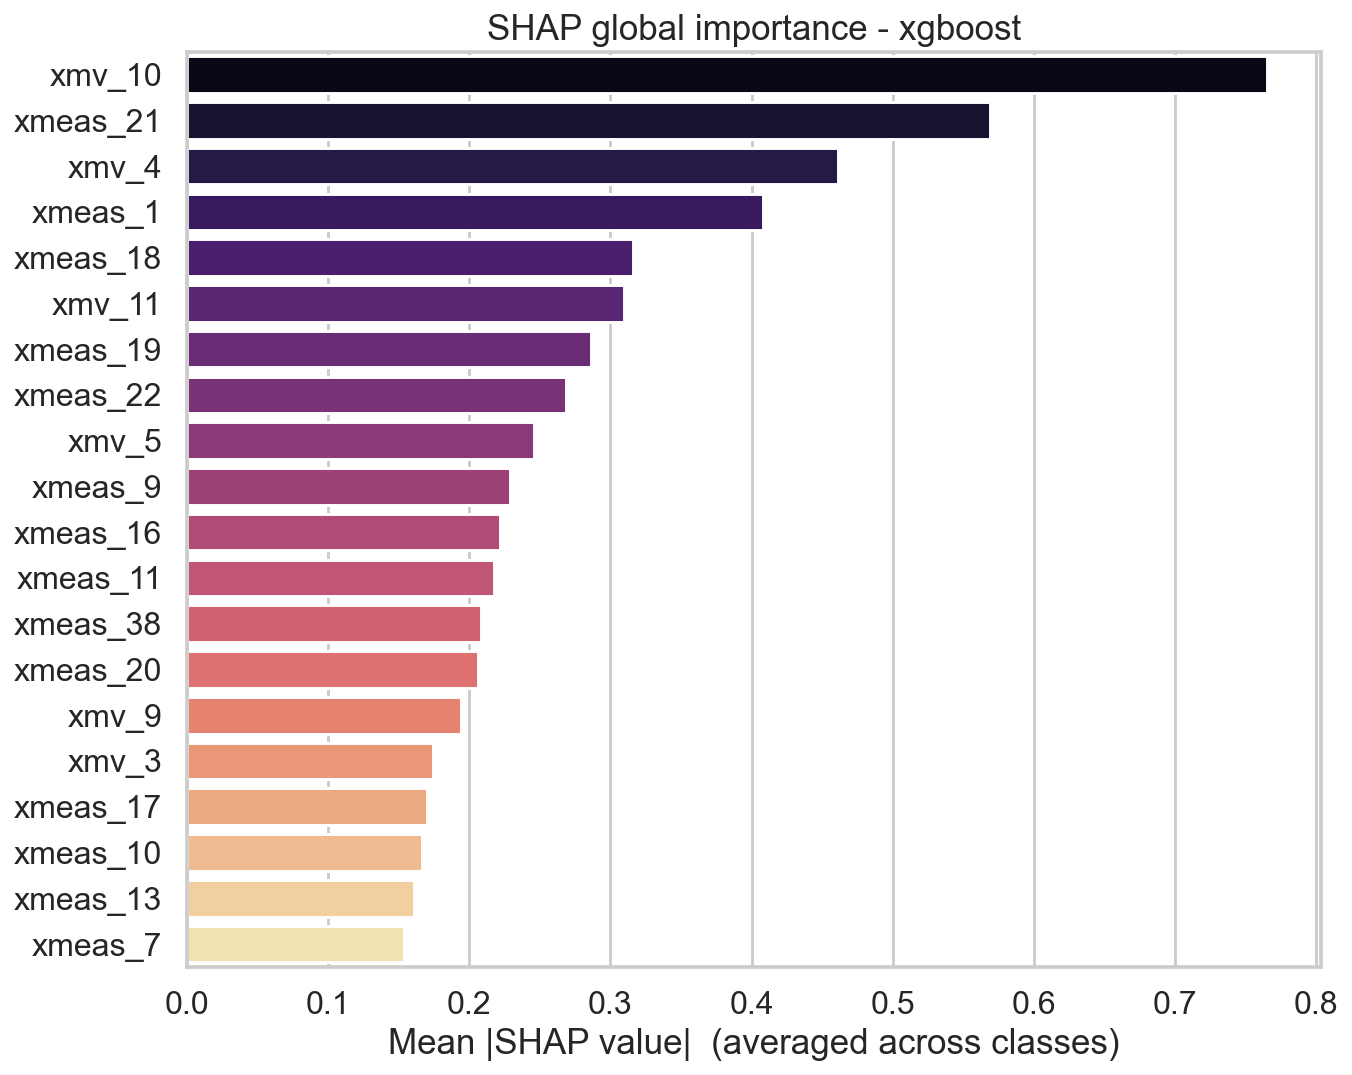

In [10]:
compute_shap_summary(best_model, ds.X_test, sample_size=500)
display(Image(filename=str(config.FIGURE_DIR / f'shap_summary_{best_model.name}.png')))

In [11]:
features, meta = stream_simulation_run(fault_number=4, split='testing', random_state=7)
alert = build_alert(features.iloc[300], best_model,
                    sample_index=int(meta['sample'].iloc[300]),
                    simulation_run=int(meta['simulationRun'].iloc[0]),
                    ground_truth=int(meta['faultNumber'].iloc[0]))
print(alert.pretty())
print(f"Stage-3 risk fusion -> score={alert.risk_score:.3f}, level={alert.risk_level}")
print('\nTop contributing sensors:')
for f in alert.top_features:
    print(f"  {f['feature']:>8s}  z={f['z_score']:+.2f}  contrib={f['contribution']:+.4f}")

Plant Status:        ALERT
Predicted Fault:     Reactor Cooling Inlet Temperature Step
Confidence:          99.0%
Severity:            HIGH
Risk Score:          0.842 (HIGH)
Recommended Action:  Inspect reactor cooling water supply, heat-exchanger fouling, cooling tower.
Stage-3 risk fusion -> score=0.842, level=HIGH

Top contributing sensors:
   xmeas_1  z=+0.38  contrib=+0.0548
   xmeas_5  z=-1.39  contrib=-0.0378
     xmv_4  z=-0.42  contrib=-0.0239
    xmv_10  z=+0.29  contrib=+0.0189
  xmeas_10  z=-0.23  contrib=-0.0129


In [12]:
# Generate dashboard-ready demo streams (one JSON per fault, written to outputs/predictions/)
paths = generate_demo_alerts(best_model, fault_ids=(0, 1, 4, 6, 11, 14), sample_every=20)
for p in paths:
    print(p)

2026-05-11 13:59:07,853 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_00_run_426.json
2026-05-11 13:59:13,453 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_01_run_426.json
2026-05-11 13:59:18,873 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_04_run_426.json
2026-05-11 13:59:23,737 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_06_run_426.json
2026-05-11 13:59:30,111 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_11_run_426.json
2026-05-11 13:59:34,917 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_14_run_426.json


C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_00_run_426.json
C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_01_run_426.json
C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_04_run_426.json
C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_06_run_426.json
C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_11_run_426.json
C:\Users\LithiChang\AIFI-group_project\outputs\predictions\stream_fault_14_run_426.json


## Next steps

* `uvicorn api.main:app --reload --port 8000` exposes `/predict`, `/simulate/{fault_id}`, `/metrics` and the demo streams via REST.
* The Next.js dashboard can fetch `/demo/stream_fault_04_run_*.json` to drive an animated reactor view.
* Re-run `python -m src.pipeline --help` for all CLI options (same data regime and 70/15/15 split as this notebook).
* Artifacts: `outputs/reports/training_summary.md`, `model_metrics.json`, figures under `outputs/figures/`.